# Módulo 14 · Lección 1 — statsforecast: forecasting a escala

Curso: **Series Temporales con R y Python** (Frogames Formación).

Este notebook es el código de acompañamiento de la lección `01-statsforecast-forecasting-a-escala`.
Compara `pmdarima` (ajuste serie a serie, ya usado en el Módulo 11 del curso) contra `statsforecast`
de Nixtla (ajuste de muchas series a la vez, con aceleración JIT) sobre el **mismo modelo AutoARIMA** y
los **mismos datos reales**: precios de cierre semanales de 102 valores cotizados de EE. UU.

**Entorno**: este módulo necesita su propio entorno virtual — ver `requirements.txt` en esta misma
carpeta. La única diferencia frente al entorno del resto del curso es `pandas==2.3.3` en vez de
`pandas==3.0.5` (las versiones actuales de `statsforecast` no soportan pandas 3.x todavía). Todo lo
demás — `scipy`, `numpy`, `statsmodels`, `pmdarima`, `yfinance` — usa exactamente las mismas versiones
que el resto del curso.

In [1]:
# Opcional: así se descargaron los datos de partida. No hace falta ejecutar esta celda
# para seguir el resto del notebook (el CSV ya está en esta carpeta).

import yfinance as yf

tickers = [
    "AAPL","MSFT","GOOGL","AMZN","META","NVDA","ORCL","ADBE","CRM","INTC",
    "CSCO","IBM","QCOM","TXN","AMD","NOW","INTU","AMAT","MU","ADI",
    "JPM","BAC","WFC","GS","MS","C","AXP","BLK","SCHW","USB",
    "UNH","JNJ","PFE","MRK","ABBV","LLY","TMO","ABT","BMY","AMGN",
    "PG","KO","PEP","WMT","HD","MCD","NKE","SBUX","TGT","COST",
    "CAT","BA","HON","MMM","GE","UPS","LMT","RTX","DE","UNP",
    "XOM","CVX","COP","SLB","EOG",
    "VZ","T","DIS","CMCSA","NFLX",
    "NEE","DUK","SO","D","AEP",
    "LIN","APD","ECL","SHW","FCX",
    "AMT","PLD","CCI","EQIX","SPG",
    "V","MA","PYPL","ADP","CB","ICE","SPGI","MET","PRU","TRV",
    "GM","F","TSLA",
    "LOW","TJX","BKNG","MAR","CL",
]
df_live = yf.download(tickers, start="2021-01-01", end="2026-09-16", interval="1d",
                       threads=False, auto_adjust=True)
close_live = df_live["Close"].dropna(axis=1, thresh=int(len(df_live) * 0.95))
print(close_live.shape)
# close_live.to_csv("raw_daily_close_102_tickers.csv")

[                       0%                       ]

[*                      2%                       ]  2 of 103 completed

[*                      3%                       ]  3 of 103 completed

[**                     4%                       ]  4 of 103 completed

[**                     5%                       ]  5 of 103 completed

...

[**********************98%********************** ]  101 of 103 completed

[**********************99%***********************]  102 of 103 completed

[*********************100%***********************]  103 of 103 completed

[*********************100%***********************]  103 of 103 completed

(1431, 103)


## Preparación: de precios diarios a formato largo semanal

`statsforecast` exige el mismo formato "largo" que ya usan casi todas las librerías de forecasting a
escala: tres columnas, `unique_id` (qué serie es), `ds` (la fecha) y `y` (el valor). `pmdarima`, en
cambio, se usa serie a serie sobre el formato "ancho" habitual (una columna por ticker) que ya conoces
de módulos anteriores.

In [2]:
import pandas as pd

close = pd.read_csv("raw_daily_close_102_tickers.csv", index_col=0, parse_dates=True)
close = close.asfreq("B").ffill()          # huecos de festivo, igual que en el Módulo 1
weekly = close.resample("W-FRI").last()    # cierre semanal: 102 series, ~300 observaciones cada una

long_df = (weekly.reset_index()
                 .melt(id_vars="Date", var_name="unique_id", value_name="y")
                 .rename(columns={"Date": "ds"})
                 .dropna())

print("formato ancho (pmdarima):", weekly.shape)
print("formato largo (statsforecast):", long_df.shape)
long_df.head()

formato ancho (pmdarima): (298, 102)
formato largo (statsforecast): (30396, 3)


,ds,unique_id,y
0,2021-01-08,AAPL,128.195419
1,2021-01-15,AAPL,123.428749
2,2021-01-22,AAPL,135.010513
3,2021-01-29,AAPL,128.108063
4,2021-02-05,AAPL,132.966309


## pmdarima: un `auto_arima` por ticker, en bucle

Es exactamente el mismo `pmdarima.auto_arima` del Módulo 11, aplicado 102 veces seguidas — una por
cada serie. Se cronometra el tiempo total.

In [3]:
import time
import warnings
warnings.filterwarnings("ignore")
import pmdarima as pm

t0 = time.time()
pmd_orders = {}
for col in weekly.columns:
    serie = weekly[col].dropna()
    modelo = pm.auto_arima(serie, seasonal=False, stepwise=True,
                            suppress_warnings=True, error_action="ignore")
    pmd_orders[col] = modelo.order
pmdarima_time = time.time() - t0

print(f"pmdarima (bucle de {len(weekly.columns)} series): {pmdarima_time:.2f} s")
print("orden elegido para AAPL:", pmd_orders["AAPL"])

pmdarima (bucle de 102 series): 29.86 s
orden elegido para AAPL: (2, 1, 2)


## statsforecast: el mismo AutoARIMA, todas las series a la vez

`StatsForecast` recibe el DataFrame largo completo y ajusta las 102 series en paralelo
(`n_jobs=-1`, un proceso por núcleo disponible), con el motor de `AutoARIMA` compilado con Numba.

In [4]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

t0 = time.time()
sf = StatsForecast(models=[AutoARIMA(season_length=1)], freq="W-FRI", n_jobs=-1)
sf.fit(long_df)
forecast = sf.predict(h=4)
sf_time = time.time() - t0

print(f"statsforecast (paralelo, {len(weekly.columns)} series): {sf_time:.2f} s")
print(f"speedup: {pmdarima_time / sf_time:.2f}x")
forecast.head(8)

statsforecast (paralelo, 102 series): 5.64 s
speedup: 5.29x


,unique_id,ds,AutoARIMA
0,AAPL,2026-09-25,332.771973
1,AAPL,2026-10-02,334.774540
2,AAPL,2026-10-09,333.220616
3,AAPL,2026-10-16,336.483518
4,ABBV,2026-09-25,264.156751
5,ABBV,2026-10-02,263.525954
6,ABBV,2026-10-09,264.117788
7,ABBV,2026-10-16,264.709621


## La misma comparación a menor escala (25 series)

Para ver cómo cambia la ventaja con el número de series, se repite exactamente el mismo experimento
con un subconjunto de solo 25 tickers.

In [5]:
tickers_25 = weekly.columns[:25]
weekly_25 = weekly[tickers_25]
long_25 = (weekly_25.reset_index()
                     .melt(id_vars="Date", var_name="unique_id", value_name="y")
                     .rename(columns={"Date": "ds"})
                     .dropna())

t0 = time.time()
for col in weekly_25.columns:
    serie = weekly_25[col].dropna()
    pm.auto_arima(serie, seasonal=False, stepwise=True, suppress_warnings=True, error_action="ignore")
pmdarima_time_25 = time.time() - t0

t0 = time.time()
sf25 = StatsForecast(models=[AutoARIMA(season_length=1)], freq="W-FRI", n_jobs=-1)
sf25.fit(long_25)
sf25.predict(h=4)
sf_time_25 = time.time() - t0

print(f"25 series — pmdarima: {pmdarima_time_25:.2f} s | statsforecast: {sf_time_25:.2f} s "
      f"| speedup: {pmdarima_time_25 / sf_time_25:.2f}x")
print(f"102 series — pmdarima: {pmdarima_time:.2f} s | statsforecast: {sf_time:.2f} s "
      f"| speedup: {pmdarima_time / sf_time:.2f}x")

25 series — pmdarima: 7.94 s | statsforecast: 5.16 s | speedup: 1.54x
102 series — pmdarima: 29.86 s | statsforecast: 5.64 s | speedup: 5.29x


## Gráfico: tiempo total vs. número de series

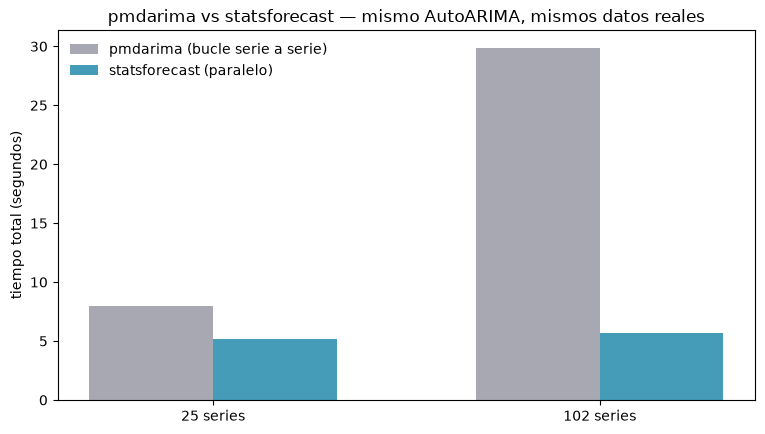

In [6]:
import matplotlib.pyplot as plt

ns = [25, len(weekly.columns)]
pmd = [pmdarima_time_25, pmdarima_time]
sfc = [sf_time_25, sf_time]

fig, ax = plt.subplots(figsize=(9, 4.8))
width = 0.32
x = range(len(ns))
ax.bar([i - width/2 for i in x], pmd, width, label="pmdarima (bucle serie a serie)", color="#a8a8b3")
ax.bar([i + width/2 for i in x], sfc, width, label="statsforecast (paralelo)", color="#449cb9")
ax.set_xticks(list(x)); ax.set_xticklabels([f"{n} series" for n in ns])
ax.set_ylabel("tiempo total (segundos)")
ax.set_title("pmdarima vs statsforecast — mismo AutoARIMA, mismos datos reales")
ax.legend(frameon=False)
plt.show()